# Exploratory Data Analysis: Two-Column Click Behavior in Qilin

This notebook presents the exploratory data analysis (EDA) for my MSc thesis on click modeling in two-column search and recommendation interfaces.

The goal of this EDA is to understand how click behavior is distributed across position, row, and column in a two-column layout. In particular, I investigate whether user clicks show evidence of examination bias and whether a one-dimensional rank-based view may be insufficient for this interface.

This notebook uses the recommendation part of the Qilin dataset.

In [2]:
from datasets import load_dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

In [3]:
ds1 = load_dataset("THUIR/Qilin", "recommendation_train")
ds2 = load_dataset("THUIR/Qilin", "recommendation_test")

df1 = ds1["train"].to_pandas()
df2 = ds2["train"].to_pandas()

df = pd.concat([df1, df2], ignore_index=True)

In [4]:
print(df.shape)
print(df.columns)
# df.head()

(94552, 7)
Index(['recent_clicked_note_idxs', 'request_idx', 'session_idx', 'user_idx',
       'query', 'rec_result_details_with_idx', 'rec_results'],
      dtype='str')


## Dataset overview

The recommendation data is stored at the request level. Each row corresponds to a recommendation request and contains a list of recommended items together with interaction information.

For click modeling, the request-level format is not yet suitable. Therefore, I transform the nested recommendation results into an item-level table, where each row corresponds to one displayed item.

This makes it possible to analyze click probability at the level of individual displayed positions.

In [5]:
df.loc[0, "rec_result_details_with_idx"]

array([{'click': 1, 'collect': 0, 'comment': 0, 'like': 0, 'note_idx': 885037, 'page_time': 0.0, 'position': 7, 'request_timestamp': 1732110732.0, 'share': 0},
       {'click': 0, 'collect': 0, 'comment': 0, 'like': 0, 'note_idx': 738980, 'page_time': 0.0, 'position': 5, 'request_timestamp': 1732110732.0, 'share': 0},
       {'click': 0, 'collect': 0, 'comment': 0, 'like': 0, 'note_idx': 580177, 'page_time': 0.0, 'position': 6, 'request_timestamp': 1732110732.0, 'share': 0},
       {'click': 0, 'collect': 0, 'comment': 0, 'like': 0, 'note_idx': 1466260, 'page_time': 0.0, 'position': 8, 'request_timestamp': 1732110732.0, 'share': 0},
       {'click': 0, 'collect': 0, 'comment': 0, 'like': 0, 'note_idx': 1639858, 'page_time': 0.0, 'position': 9, 'request_timestamp': 1732110744.0, 'share': 0},
       {'click': 0, 'collect': 0, 'comment': 0, 'like': 0, 'note_idx': 784889, 'page_time': 0.0, 'position': 10, 'request_timestamp': 1732110744.0, 'share': 0},
       {'click': 0, 'collect': 0, 'co

## Transforming the nested results into item-level observations

The column `rec_result_details_with_idx` contains the displayed recommendation results for each request. Each element includes variables such as click and position.

To analyze position effects, I convert this nested structure into a flat table in which each row corresponds to one displayed item. This is the main table used in the remainder of the EDA.

In [6]:
result_df = df[["session_idx", "request_idx", "rec_result_details_with_idx"]].explode("rec_result_details_with_idx")
result_df = result_df[result_df["rec_result_details_with_idx"].notna()].copy()
result_df.head()

,session_idx,request_idx,rec_result_details_with_idx
0,55877,23194,"{'click': 1, 'collect': 0, 'comment': 0, 'like..."
0,55877,23194,"{'click': 0, 'collect': 0, 'comment': 0, 'like..."
0,55877,23194,"{'click': 0, 'collect': 0, 'comment': 0, 'like..."
0,55877,23194,"{'click': 0, 'collect': 0, 'comment': 0, 'like..."
0,55877,23194,"{'click': 0, 'collect': 0, 'comment': 0, 'like..."


In [7]:
result_df = result_df.reset_index(drop=True)

details_df = pd.json_normalize(result_df["rec_result_details_with_idx"])

result_df = pd.concat(
    [result_df[["session_idx", "request_idx"]], details_df],
    axis=1
)

result_df.head()

,session_idx,request_idx,click,collect,comment,like,note_idx,page_time,position,request_timestamp,share
0,55877,23194,1,0,0,0,885037,0.0,7,1.732111e+09,0
1,55877,23194,0,0,0,0,738980,0.0,5,1.732111e+09,0
2,55877,23194,0,0,0,0,580177,0.0,6,1.732111e+09,0
3,55877,23194,0,0,0,0,1466260,0.0,8,1.732111e+09,0
4,55877,23194,0,0,0,0,1639858,0.0,9,1.732111e+09,0


In [8]:
print(result_df.columns)
result_df.head()

Index(['session_idx', 'request_idx', 'click', 'collect', 'comment', 'like',
       'note_idx', 'page_time', 'position', 'request_timestamp', 'share'],
      dtype='str')


,session_idx,request_idx,click,collect,comment,like,note_idx,page_time,position,request_timestamp,share
0,55877,23194,1,0,0,0,885037,0.0,7,1.732111e+09,0
1,55877,23194,0,0,0,0,738980,0.0,5,1.732111e+09,0
2,55877,23194,0,0,0,0,580177,0.0,6,1.732111e+09,0
3,55877,23194,0,0,0,0,1466260,0.0,8,1.732111e+09,0
4,55877,23194,0,0,0,0,1639858,0.0,9,1.732111e+09,0


## Selecting variables for the EDA

For this exploratory analysis, I focus on variables that are directly relevant to click behavior and examination bias:

- `session_idx`: identifies the session
- `request_idx`: identifies the recommendation request
- `note_idx`: identifies the item
- `position`: the shown rank/index
- `click`: whether the item was clicked

The analysis later derives `row` and `column` from `position` to represent the two-column layout explicitly.

In [9]:
result_df = result_df[["session_idx", "request_idx", "note_idx", "position", "click"]].copy()
result_df.head()

,session_idx,request_idx,note_idx,position,click
0,55877,23194,885037,7,1
1,55877,23194,738980,5,0
2,55877,23194,580177,6,0
3,55877,23194,1466260,8,0
4,55877,23194,1639858,9,0


In [10]:
print("Minimum position:", result_df["position"].min())
print("Maximum position:", result_df["position"].max())
result_df["position"].value_counts().sort_index().head(10)

Minimum position: 1
Maximum position: 293


position
1     97715
2     98250
3     98013
4     90186
5     52504
6     52650
7     46883
8     45236
9     39585
10    37725
Name: count, dtype: int64

## Constructing row and column from position

The interface is treated as a two-column layout. Therefore, the one-dimensional `position` variable is mapped to:

- `row`: vertical placement
- `column`: horizontal placement

Because the minimum observed position is checked directly in the data, row and column are derived from the observed indexing scheme rather than assumed in advance.

In [11]:
result_df["row"] = (result_df["position"] - 1) // 2
result_df["column"] = (result_df["position"] - 1) % 2

In [12]:
result_df[["position", "row", "column", "click"]].head(20)

,position,row,column,click
0,7,3,0,1
1,5,2,0,0
2,6,2,1,0
3,8,3,1,0
4,9,4,0,0
5,10,4,1,0
6,11,5,0,0
7,12,5,1,0
8,1,0,0,1
9,2,0,1,0


The constructed variables represent the interface layout more directly than a single rank variable.

- `row = 0` contains the first visible row
- `column = 0` and `column = 1` represent the left and right positions within each row

This transformation allows the analysis to test whether click behavior depends not only on vertical rank, but also on horizontal placement.

In [13]:
result_df.isna().sum()

session_idx    0
request_idx    0
note_idx       0
position       0
click          0
row            0
column         0
dtype: int64

In [15]:
clean_df = result_df.dropna(subset=["position", "click", "row", "column"]).copy()

clean_df["position"] = clean_df["position"].astype(int)
clean_df["click"]    = clean_df["click"].astype(int)
clean_df["row"]      = clean_df["row"].astype(int)
clean_df["column"]   = clean_df["column"].astype(int)

# Filter positions with fewer than 1000 impressions — consistent with model notebook
position_counts  = clean_df["position"].value_counts()
valid_positions  = position_counts[position_counts >= 1000].index
clean_df         = clean_df[clean_df["position"].isin(valid_positions)].copy()

print("Valid positions kept:", len(valid_positions))
print("Max position:", clean_df["position"].max())
print("Shape after filtering:", clean_df.shape)

clean_df.head()

Valid positions kept: 76
Max position: 76
Shape after filtering: (1429066, 7)


,session_idx,request_idx,note_idx,position,click,row,column
0,55877,23194,885037,7,1,3,0
1,55877,23194,738980,5,0,2,0
2,55877,23194,580177,6,0,2,1
3,55877,23194,1466260,8,0,3,1
4,55877,23194,1639858,9,0,4,0


## Basic sanity checks

Before interpreting click-through rates, I first inspect the size and balance of the cleaned impression-level dataset. This is important because CTR estimates can become unstable when some positions have very few observations.

In [16]:
print("Total rows:", len(clean_df))
print("Unique sessions:", clean_df["session_idx"].nunique())
print("Unique requests:", clean_df["request_idx"].nunique())

clean_df["click"].value_counts(normalize=True)

Total rows: 1429066
Unique sessions: 59903
Unique requests: 94552


click
0    0.758318
1    0.241682
Name: proportion, dtype: float64

In [17]:
clean_df.describe()

,session_idx,request_idx,note_idx,position,click,row,column
count,1.429066e+06,1.429066e+06,1.429066e+06,1.429066e+06,1.429066e+06,1.429066e+06,1.429066e+06
mean,6.256481e+04,4.767047e+04,1.115458e+06,1.822951e+01,2.416823e-01,8.367927e+00,4.936539e-01
std,1.732189e+04,2.754438e+04,4.941972e+05,1.711200e+01,4.281029e-01,8.552291e+00,4.999599e-01
min,3.277000e+04,0.000000e+00,5.726000e+03,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,4.749900e+04,2.375900e+04,7.971932e+05,4.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00
50%,6.251400e+04,4.785200e+04,1.157599e+06,1.200000e+01,0.000000e+00,5.000000e+00,0.000000e+00
75%,7.754600e+04,7.167100e+04,1.512657e+06,2.800000e+01,0.000000e+00,1.300000e+01,1.000000e+00
max,9.267200e+04,9.455100e+04,1.983937e+06,7.600000e+01,1.000000e+00,3.700000e+01,1.000000e+00


## CTR by position

As a baseline view, I compute CTR by linear position. This checks whether standard position bias is present: items shown earlier should receive more clicks.

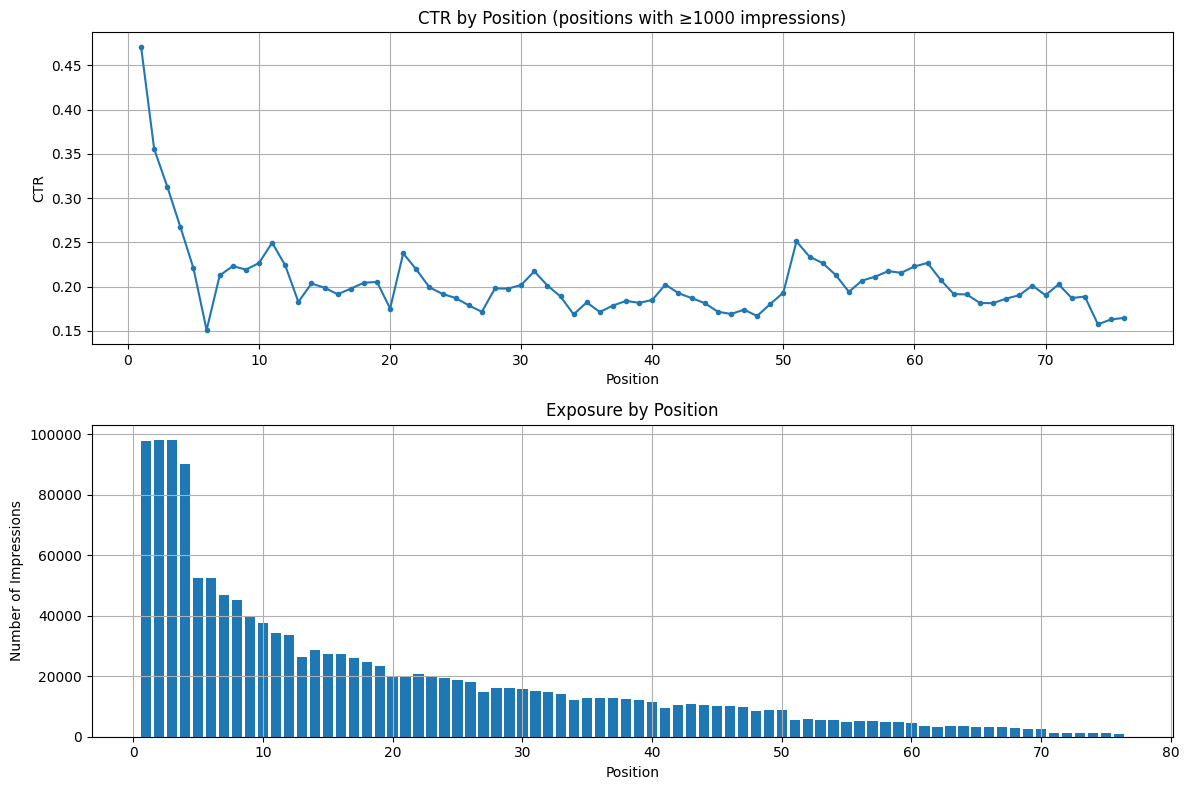

Positions retained: 76
Max position: 76
Total impressions: 1429066


In [18]:
ctr_position      = clean_df.groupby("position")["click"].mean()
exposure_position = clean_df.groupby("position").size()

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].plot(ctr_position.index, ctr_position.values, marker="o", markersize=3)
axes[0].set_xlabel("Position")
axes[0].set_ylabel("CTR")
axes[0].set_title("CTR by Position (positions with ≥1000 impressions)")
axes[0].grid(True)

axes[1].bar(exposure_position.index, exposure_position.values, width=0.8)
axes[1].set_xlabel("Position")
axes[1].set_ylabel("Number of Impressions")
axes[1].set_title("Exposure by Position")
axes[1].grid(True)

plt.tight_layout()
plt.savefig("ctr_and_exposure_by_position.png", dpi=150)
plt.show()

print(f"Positions retained: {clean_df['position'].nunique()}")
print(f"Max position: {clean_df['position'].max()}")
print(f"Total impressions: {len(clean_df)}")

## CTR by row

This plot aggregates click behavior at the row level. If CTR decreases with row, this suggests vertical position bias: users are more likely to examine items near the top of the interface.

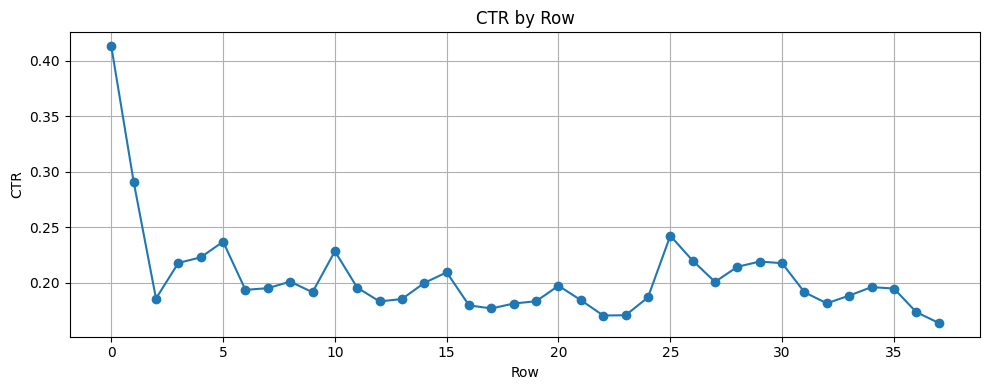

CTR by row:
row
0     0.4133
1     0.2912
2     0.1857
3     0.2178
4     0.2229
5     0.2370
6     0.1935
7     0.1951
8     0.2010
9     0.1914
10    0.2284
11    0.1955
12    0.1831
13    0.1853
14    0.1998
15    0.2093
16    0.1795
17    0.1768
18    0.1812
19    0.1833
20    0.1972
21    0.1843
22    0.1704
23    0.1706
24    0.1867
25    0.2424
26    0.2199
27    0.2007
28    0.2143
29    0.2191
30    0.2176
31    0.1914
32    0.1814
33    0.1884
34    0.1960
35    0.1947
36    0.1735
37    0.1637


In [19]:
ctr_row = clean_df.groupby("row")["click"].mean()

plt.figure(figsize=(10, 4))
plt.plot(ctr_row.index, ctr_row.values, marker="o")
plt.xlabel("Row")
plt.ylabel("CTR")
plt.title("CTR by Row")
plt.grid(True)
plt.tight_layout()
plt.savefig("ctr_by_row.png", dpi=150)
plt.show()

print("CTR by row:")
print(ctr_row.round(4).to_string())

## CTR by column

This analysis tests whether horizontal placement matters. If the two columns have different CTR, then a purely one-dimensional ranked-list view may miss part of the examination process.

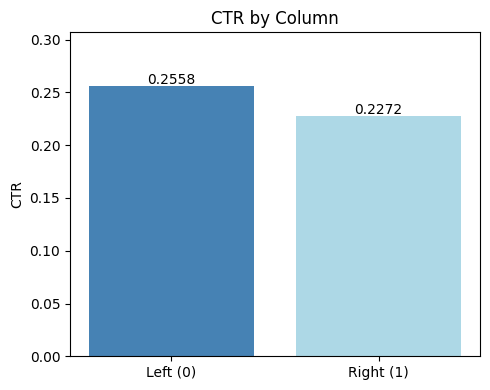

=== Chi-square test: Left vs Right column CTR ===
Left CTR:  0.2558
Right CTR: 0.2272
Chi2: 1587.56  df: 1  p-value: 0.000000
Conclusion: Statistically significant difference


In [20]:
ctr_column = clean_df.groupby("column")["click"].mean()

plt.figure(figsize=(5, 4))
plt.bar(["Left (0)", "Right (1)"], ctr_column.values, color=["steelblue", "lightblue"])
plt.ylabel("CTR")
plt.title("CTR by Column")
plt.ylim(0, ctr_column.max() * 1.2)
for i, v in enumerate(ctr_column.values):
    plt.text(i, v + 0.002, f"{v:.4f}", ha="center")
plt.tight_layout()
plt.savefig("ctr_by_column.png", dpi=150)
plt.show()

# Chi-square test for column CTR difference
contingency = pd.crosstab(clean_df["column"], clean_df["click"])
chi2, p, dof, expected = chi2_contingency(contingency)

print("=== Chi-square test: Left vs Right column CTR ===")
print(f"Left CTR:  {ctr_column[0]:.4f}")
print(f"Right CTR: {ctr_column[1]:.4f}")
print(f"Chi2: {chi2:.2f}  df: {dof}  p-value: {p:.6f}")
print(f"Conclusion: {'Statistically significant difference' if p < 0.05 else 'No significant difference'}")

## Column CTR by Row — Anomaly Check

This table shows CTR for left and right columns separately for each row.

- If left CTR consistently exceeds right CTR, that confirms a left-column advantage.
- Rows where right CTR exceeds left CTR are anomalies worth investigating.
- A consistent anomaly at a specific row suggests a scanning pattern deviation rather than noise.

In [22]:
print("=== Column CTR by Row (all rows) ===")
print(f"{'Row':<6} {'Left CTR':>10} {'Right CTR':>11} {'Left > Right':>14}")
print("-" * 45)

for row in sorted(clean_df["row"].unique()):
    subset     = clean_df[clean_df["row"] == row]
    left_ctr   = subset[subset["column"] == 0]["click"].mean()
    right_ctr  = subset[subset["column"] == 1]["click"].mean()
    flag       = "YES" if left_ctr > right_ctr else "NO ← anomaly"
    print(f"{row:<6} {left_ctr:>10.4f} {right_ctr:>11.4f} {flag:>14}")


=== Column CTR by Row (all rows) ===
Row      Left CTR   Right CTR   Left > Right
---------------------------------------------
0          0.4714      0.3556            YES
1          0.3130      0.2674            YES
2          0.2206      0.1509            YES
3          0.2126      0.2232   NO ← anomaly
4          0.2192      0.2267   NO ← anomaly
5          0.2497      0.2239            YES
6          0.1827      0.2036   NO ← anomaly
7          0.1987      0.1914            YES
8          0.1977      0.2044   NO ← anomaly
9          0.2054      0.1753            YES
10         0.2376      0.2194            YES
11         0.1992      0.1918            YES
12         0.1871      0.1789            YES
13         0.1715      0.1979   NO ← anomaly
14         0.1978      0.2019   NO ← anomaly
15         0.2174      0.2013            YES
16         0.1889      0.1686            YES
17         0.1823      0.1713            YES
18         0.1787      0.1838   NO ← anomaly
19         0.1817

In [23]:
ctr_2d = clean_df.pivot_table(
    values="click",
    index="row",
    columns="column",
    aggfunc="mean"
)

ctr_2d

column,0,1
row,,
0,0.471391,0.355573
1,0.313020,0.267425
2,0.220631,0.150940
3,0.212614,0.223207
4,0.219250,0.226693
5,0.249717,0.223944
6,0.182686,0.203554
7,0.198747,0.191381
8,0.197742,0.204356


## CTR heatmap by (row, column)

This heatmap shows CTR for each two-dimensional position in the layout. Under a purely one-dimensional model, both cells within a row would be expected to behave similarly. Visible within-row differences motivate the two-dimensional extension. The exposure count heatmap is shown alongside to confirm that observed patterns are not driven by data sparsity.

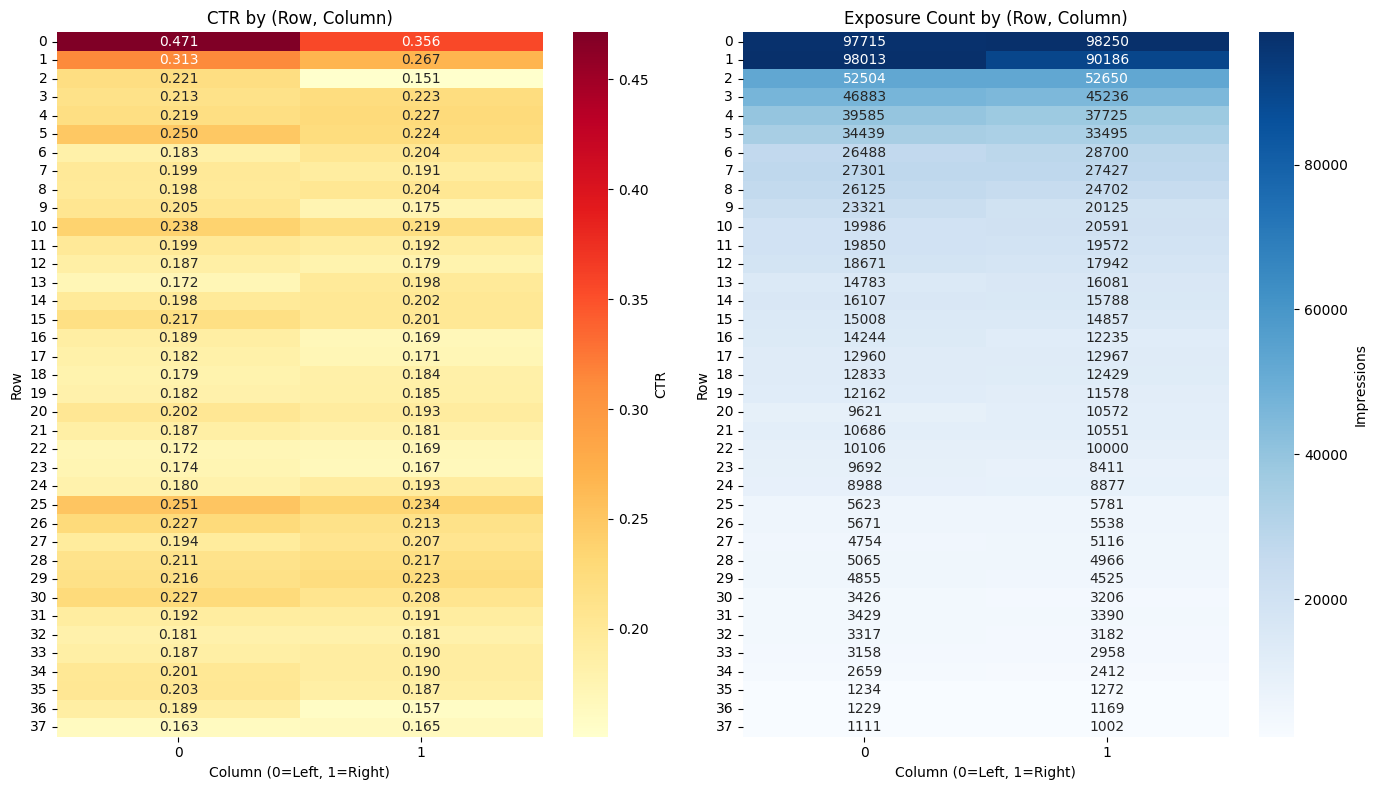

In [24]:
exposure_2d = clean_df.pivot_table(
    values="click",
    index="row",
    columns="column",
    aggfunc="count"
)

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

sns.heatmap(ctr_2d, annot=True, fmt=".3f", cmap="YlOrRd",
            ax=axes[0], cbar_kws={"label": "CTR"})
axes[0].set_title("CTR by (Row, Column)")
axes[0].set_xlabel("Column (0=Left, 1=Right)")
axes[0].set_ylabel("Row")

sns.heatmap(exposure_2d, annot=True, fmt=".0f", cmap="Blues",
            ax=axes[1], cbar_kws={"label": "Impressions"})
axes[1].set_title("Exposure Count by (Row, Column)")
axes[1].set_xlabel("Column (0=Left, 1=Right)")
axes[1].set_ylabel("Row")

plt.tight_layout()
plt.savefig("ctr_and_exposure_heatmap.png", dpi=150)
plt.show()

In [62]:
# Sort by position (top first)
clean_df_sorted = clean_df.sort_values(by=["session_idx", "position"])

# Get first click per session
first_clicks = clean_df_sorted[clean_df_sorted["click"] == 1] \
    .groupby("session_idx") \
    .first()

first_clicks[["row", "column"]].head(20)

,row,column
session_idx,,
32770,1,0
32771,10,0
32772,1,0
32773,1,0
32775,1,1
32777,1,0
32778,1,0
32779,1,1
32781,1,0


## Exposure by row

To determine which rows are reliable enough to interpret, I inspect the number of impressions per row. Deep rows may contain too little data for stable CTR estimates.

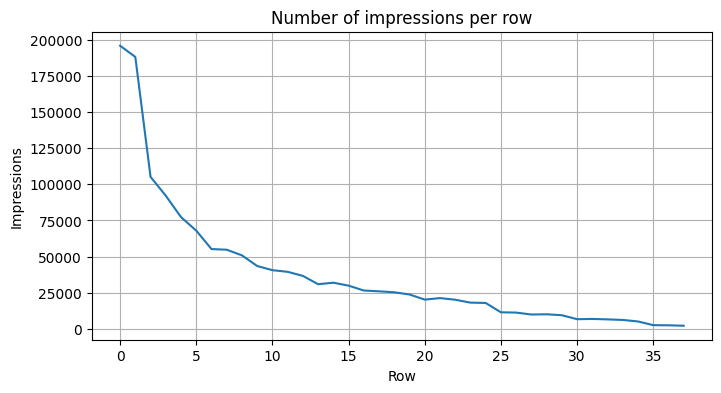

(row
 0     195965
 1     188199
 2     105154
 3      92119
 4      77310
 5      67934
 6      55188
 7      54728
 8      50827
 9      43446
 10     40577
 11     39422
 12     36613
 13     30864
 14     31895
 15     29865
 16     26479
 17     25927
 18     25262
 19     23740
 dtype: int64,
 row
 18    25262
 19    23740
 20    20193
 21    21237
 22    20106
 23    18103
 24    17865
 25    11404
 26    11209
 27     9870
 28    10031
 29     9380
 30     6632
 31     6819
 32     6499
 33     6116
 34     5071
 35     2506
 36     2398
 37     2113
 dtype: int64)

In [26]:
counts_row = clean_df.groupby("row").size()

plt.figure(figsize=(8,4))
counts_row.plot()
plt.xlabel("Row")
plt.ylabel("Impressions")
plt.title("Number of impressions per row")
plt.grid(True)
plt.show()

counts_row.head(20), counts_row.tail(20)

## First-click analysis

As an exploratory proxy for examination order, I inspect the position of the first click within each request. If first clicks are concentrated in the top-left area, this is consistent with a top-down, left-to-right scanning pattern.

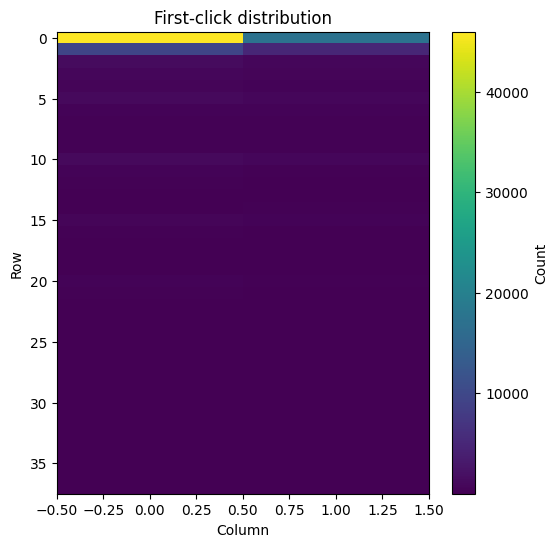

In [27]:
first_clicks = (
    clean_df[clean_df["click"] == 1]
    .sort_values(["session_idx", "request_idx", "position"])
    .groupby(["session_idx", "request_idx"])
    .first()
    .reset_index()
)

first_click_dist = first_clicks.pivot_table(
    index="row",
    columns="column",
    values="click",
    aggfunc="count"
)

plt.figure(figsize=(6,6))
plt.imshow(first_click_dist, aspect="auto")
plt.colorbar(label="Count")
plt.xlabel("Column")
plt.ylabel("Row")
plt.title("First-click distribution")
plt.show()

In [28]:
print(len(clean_df))
print(clean_df["session_idx"].nunique())
print(clean_df["request_idx"].nunique())
print(clean_df["click"].mean())

1429066
59903
94552
0.24168232957750027


In [29]:
total_first_clicks = len(first_clicks)

summary = (
    first_clicks
    .groupby(["row", "column"])
    .size()
    .reset_index(name="count")
)
summary["share"] = summary["count"] / total_first_clicks

print("=== First-click distribution by (row, column) — top 10 rows ===")
print(summary[summary["row"] <= 9].to_string(index=False))

print(f"\nTotal first clicks:                    {total_first_clicks}")
print(f"Share in row 0:                        {summary[summary['row']==0]['share'].sum():.3f}")
print(f"Share in left column (col 0):          {summary[summary['column']==0]['share'].sum():.3f}")
print(f"Share in right column (col 1):         {summary[summary['column']==1]['share'].sum():.3f}")

top_left  = summary[(summary['row']==0) & (summary['column']==0)]
top_right = summary[(summary['row']==0) & (summary['column']==1)]

if len(top_left) > 0:
    print(f"Share in top-left cell (row 0, col 0): {top_left['share'].values[0]:.3f}")
if len(top_right) > 0:
    print(f"Share in top-right cell (row 0, col 1):{top_right['share'].values[0]:.3f}")

=== First-click distribution by (row, column) — top 10 rows ===
 row  column  count    share
   0       0  45978 0.486385
   0       1  17313 0.183148
   1       0   9534 0.100857
   1       1   4947 0.052333
   2       0   1330 0.014070
   2       1    776 0.008209
   3       0    841 0.008897
   3       1    702 0.007426
   4       0    556 0.005882
   4       1    496 0.005247
   5       0   1241 0.013128
   5       1    848 0.008971
   6       0    376 0.003978
   6       1    371 0.003925
   7       0    259 0.002740
   7       1    250 0.002645
   8       0    221 0.002338
   8       1    187 0.001978
   9       0    202 0.002137
   9       1    238 0.002518

Total first clicks:                    94530
Share in row 0:                        0.670
Share in left column (col 0):          0.688
Share in right column (col 1):         0.312
Share in top-left cell (row 0, col 0): 0.486
Share in top-right cell (row 0, col 1):0.183
